Load model

In [ ]:
from tensorflow.keras.models import load_model

my_model = load_model('./model/breast_cancer_model.h5')
# can use continue training without re-compiled

In [3]:
my_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131 (528.00 B)

 Trainable params: 129 (516.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [2]:
my_model.get_config()

{'name': 'sequential',
 'trainable': True,
 'dtype': {'module': 'keras',
  'class_name': 'DTypePolicy',
  'config': {'name': 'float32'},
  'registered_name': None},
 'layers': [{'module': 'keras.layers',
   'class_name': 'InputLayer',
   'config': {'batch_shape': (None, 2),
    'dtype': 'float32',
    'sparse': False,
    'ragged': False,
    'name': 'input_layer'},
   'registered_name': None},
  {'module': 'keras.layers',
   'class_name': 'Dense',
   'config': {'name': 'dense',
    'trainable': True,
    'dtype': {'module': 'keras',
     'class_name': 'DTypePolicy',
     'config': {'name': 'float32'},
     'registered_name': None},
    'units': 32,
    'activation': 'relu',
    'use_bias': True,
    'kernel_initializer': {'module': 'keras.initializers',
     'class_name': 'GlorotUniform',
     'config': {'seed': None},
     'registered_name': None},
    'bias_initializer': {'module': 'keras.initializers',
     'class_name': 'Zeros',
     'config': {},
     'registered_name': None},
  

Load Scaler

In [7]:
import pickle

sc = pickle.load(open('./myproject/scaler.pkl', 'rb'))

Load Classname

In [8]:
file_name =  './myproject/classname.pkl'
open_file = open(file_name, 'rb')
class_names = pickle.load(open_file)
open_file.close()

print(class_names)

['benign' 'malignant']


Prediction

In [14]:
X_new = [[16.4, 14.1],
         [13.5, 13.6],
         [19.69, 21.25]]

# Stadard scale data
X_new_sc = sc.transform(X_new)

d:\Programming_File\Environment\tf\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [15]:
# Predict
y_pred_pr = my_model.predict(X_new_sc)
y_pred = (y_pred_pr > 0.5).astype(int)
# Decoding
print(class_names[y_pred])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
[['benign']
 ['benign']
 ['malignant']]


Model Boundary

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 4s 447us/step


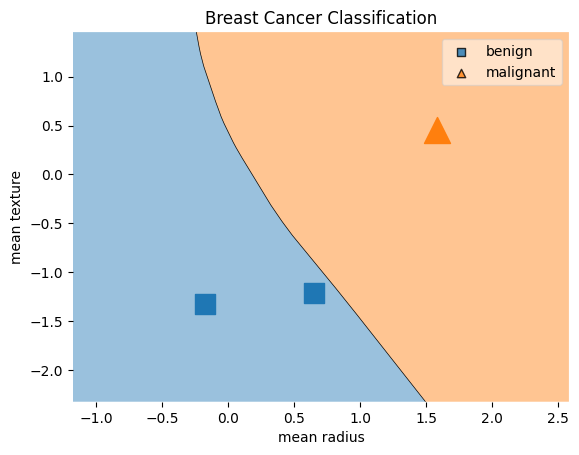

In [19]:
from mlxtend.plotting import plot_decision_regions
import matplotlib.pyplot as plt

y = y_pred.reshape(1,-1)[0]

# Create Decision Boundary
ax = plot_decision_regions(X_new_sc, y, clf=my_model)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, class_names, framealpha=0.5)

plt.xlabel('mean radius')
plt.ylabel('mean texture')
plt.title('Breast Cancer Classification')


# Plot prediction
plt.scatter(X_new_sc[:,0][y==0], X_new_sc[:,1][y==0], s=200, marker='s')
plt.scatter(X_new_sc[:,0][y==1], X_new_sc[:,1][y==1], s=350, marker='^')
plt.show()